In [1]:
import numpy
import torch
from torch import nn

Hangi klasörün içerisinde neler var ve kaç tane görsel var bunun öğrenmek için şu kodları kullanabiliriz:

In [2]:
from pathlib import Path
data_path = Path("data/")
image_path = data_path / "desert101"

Path kütüphanesi ile klasörümüzün yolunu belirledik.

In [3]:
import os
def check_data(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"# of directories: {len(dirnames)} and {len(filenames)} images in '{dirpath}'.")

In [4]:
check_data(image_path)

# of directories: 2 and 1 images in 'data/desert101'.
# of directories: 4 and 1 images in 'data/desert101/train'.
# of directories: 0 and 80 images in 'data/desert101/train/cannoli'.
# of directories: 0 and 80 images in 'data/desert101/train/baklava'.
# of directories: 0 and 80 images in 'data/desert101/train/cup_cakes'.
# of directories: 0 and 80 images in 'data/desert101/train/donuts'.
# of directories: 4 and 1 images in 'data/desert101/test'.
# of directories: 0 and 20 images in 'data/desert101/test/cannoli'.
# of directories: 0 and 20 images in 'data/desert101/test/baklava'.
# of directories: 0 and 20 images in 'data/desert101/test/cup_cakes'.
# of directories: 0 and 20 images in 'data/desert101/test/donuts'.


In [5]:
train_dir = image_path / "train"
test_dir = image_path / "test"

Data setimizde yer alan görselleri göstermek için kullandığımız kütüphane ise:

In [6]:
import random
from PIL import Image

random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))      # Bunu diyerek bütün .jpg uzantılı dosyaları bir liste içerisine alıyoruz.

random_image_path = random.choice(image_path_list)

img = Image.open(random_image_path)

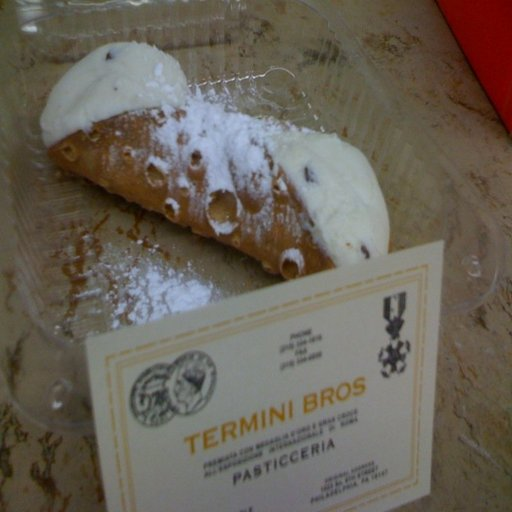

In [7]:
img

In [8]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

Şimdi transform yapmak istediğim şeyleri yazacağım.
- Görsellerin boyutlarını 64x64 yapacağım.
- Horizontal Flip yapacağım.
- Bir de görsellere rastgele uygulanan Trivial AugmentWide'ı uygulayacağım.

In [9]:
data_transform = transforms.Compose([
    transforms.Resize(size = (64, 64)),    # Boyutları 64x64 olarak ayarladım.
    transforms.RandomHorizontalFlip(p = 0.4),    # Görsellerin rastgele yüzde 40'ına uygulandı
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.4947, 0.4291, 0.3678],
                         std = [0.2898, 0.2818, 0.2796])
])

In [10]:
train_data = datasets.ImageFolder(root = train_dir,
                                  transform = data_transform)

test_data = datasets.ImageFolder(root = test_dir,
                                 transform = data_transform)

In [11]:
train_data

Dataset ImageFolder
    Number of datapoints: 316
    Root location: data/desert101/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
               Normalize(mean=[0.4947, 0.4291, 0.3678], std=[0.2898, 0.2818, 0.2796])
           )

In [12]:
test_data

Dataset ImageFolder
    Number of datapoints: 77
    Root location: data/desert101/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
               Normalize(mean=[0.4947, 0.4291, 0.3678], std=[0.2898, 0.2818, 0.2796])
           )

In [13]:
class_names = train_data.classes

In [14]:
class_names

['baklava', 'cannoli', 'cup_cakes', 'donuts']

In [15]:
len(train_data), len(test_data)

(316, 77)

Şimdi de dataloader'ları hazırlayalım.

In [16]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader = DataLoader(
    dataset = train_data,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = NUM_WORKERS
)

test_dataloader = DataLoader(
    dataset = test_data,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS
)

In [17]:
train_dataloader

In [18]:
class Desert101Classifier(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels = input_shape, out_channels = hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = hidden_units * 16 * 16, out_features = output_shape)
        )

    def forward(self, x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

nn.Linear() içerisine ne yazacağımızı hesaplamak için aşağıdaki yöntemi kullanacağız.

In [19]:
x = torch.rand([1,3,64,64])
print(x.shape)

conv1 = nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 3, stride = 1, padding = 1)
conv2 = nn.Conv2d(in_channels = 32, out_channels = 32, kernel_size = 3, stride = 1, padding = 1)
pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)

conv3 = nn.Conv2d(in_channels = 32, out_channels = 32, kernel_size = 3, stride = 1, padding = 1)
conv4 = nn.Conv2d(in_channels = 32, out_channels = 32, kernel_size = 3, stride = 1, padding = 1)
pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)

x = conv1(x)
print(f"Shape of x after 1.Conv2d {x.shape}")

x = conv2(x)
print(f"Shape of x after 2.Conv2d {x.shape}")

x = pool1(x)
print(f"Shape of x after 1.MaxPool {x.shape}")

x = conv3(x)
print(f"Shape of x after 3.Conv2d {x.shape}")

x = conv4(x)
print(f"Shape of x after 4.Conv2d {x.shape}")

x = pool2(x)
print(f"Shape of x after 2.MaxPool {x.shape}")

torch.Size([1, 3, 64, 64])
Shape of x after 1.Conv2d torch.Size([1, 32, 64, 64])
Shape of x after 2.Conv2d torch.Size([1, 32, 64, 64])
Shape of x after 1.MaxPool torch.Size([1, 32, 32, 32])
Shape of x after 3.Conv2d torch.Size([1, 32, 32, 32])
Shape of x after 4.Conv2d torch.Size([1, 32, 32, 32])
Shape of x after 2.MaxPool torch.Size([1, 32, 16, 16])


Buradan anlıyoruz ki son Lineer katmanına 32 * 16 * 16 tane nöron girmelidir.

In [20]:
!pip install torchinfo

In [21]:
from torchinfo import summary

In [22]:
torch.manual_seed(42)
model_0 = Desert101Classifier(input_shape = 3, hidden_units = 32, output_shape = len(class_names))

In [23]:
summary(model = model_0, input_size = [1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
Desert101Classifier                      [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

torchinfo kullanarak bu şekilde hangi katmandan ne çıkıyor ve boyutları ne oluyor hepsini görebiliriz.

In [24]:
def calculate_accuracy(y_pred, y_true):
    correct = torch.eq(y_pred, y_true).sum().item()
    acc = (correct / len(y_true)) * 100
    return acc

In [25]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_function):
    # Training Mode
    model.train()
    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(dataloader):
        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_function(y_pred.argmax(dim = 1), y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    return train_loss, train_acc

In [26]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_function):
    # Testing Step
    model.eval()
    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            test_pred = model(X)

            loss = loss_fn(test_pred, y)
            test_loss += loss.item()
            test_acc += accuracy_function(test_pred.argmax(dim = 1), y)

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)

    return test_loss, test_acc

In [27]:
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          accuracy_function):

    # 1-Sonuçları tutmak için boş bir sözlük oluşturdum
    results = {
        "train_loss" : [],
        "train_acc" : [],
        "test_loss" : [],
        "test_acc" : []
    }

    # 2-Eğitim döngüsünü kurdum, train ve test fonksiyonlarını çağırarak eğitimi yaptım.
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           accuracy_function=accuracy_function)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        accuracy_function=accuracy_function)

        # 3-Çıkan sonuçları yazdırdım
        print(f"Epoch: {epoch+1} | Train_loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results

In [28]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCHS = 10
model_0 = Desert101Classifier(input_shape=3,
                              hidden_units=32,
                              output_shape=len(class_names))

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

model_0_results = train(model=model_0,
      train_dataloader=train_dataloader,
      test_dataloader=test_dataloader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=EPOCHS,
      accuracy_function=calculate_accuracy)

Epoch: 1 | Train_loss: 1.3930 | Train Accuracy: 25.5804 | Test Loss: 1.3819 | Test Accuracy: 23.3974
Epoch: 2 | Train_loss: 1.3724 | Train Accuracy: 29.2411 | Test Loss: 1.3533 | Test Accuracy: 32.2917
Epoch: 3 | Train_loss: 1.3128 | Train Accuracy: 37.7679 | Test Loss: 1.4180 | Test Accuracy: 27.5641
Epoch: 4 | Train_loss: 1.2779 | Train Accuracy: 39.1964 | Test Loss: 1.2562 | Test Accuracy: 50.1603
Epoch: 5 | Train_loss: 1.2756 | Train Accuracy: 38.8393 | Test Loss: 1.4265 | Test Accuracy: 35.3365
Epoch: 6 | Train_loss: 1.2413 | Train Accuracy: 46.6964 | Test Loss: 1.3074 | Test Accuracy: 37.8205
Epoch: 7 | Train_loss: 1.2153 | Train Accuracy: 45.5357 | Test Loss: 1.1454 | Test Accuracy: 43.0288
Epoch: 8 | Train_loss: 1.2324 | Train Accuracy: 46.1161 | Test Loss: 1.2444 | Test Accuracy: 36.8590
Epoch: 9 | Train_loss: 1.2080 | Train Accuracy: 41.5625 | Test Loss: 1.3333 | Test Accuracy: 29.1667
Epoch: 10 | Train_loss: 1.1842 | Train Accuracy: 44.5536 | Test Loss: 1.2113 | Test Accurac

In [29]:
import matplotlib.pyplot as plt

In [30]:
def plt_curves(results):
    train_loss = results["train_loss"]
    test_loss = results["test_loss"]
    train_acc = results["train_acc"]
    test_acc = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(12,6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label = 'Train Loss')
    plt.plot(epochs, test_loss, label = 'Test Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label = 'Train Accuracy')
    plt.plot(epochs, test_acc, label = 'Test Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

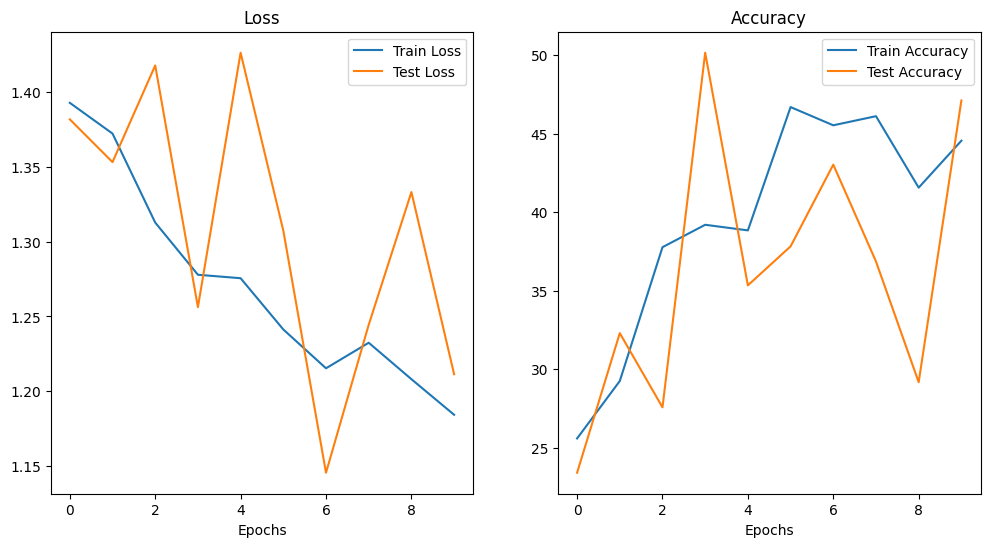

In [31]:
plt_curves(model_0_results)

In [32]:
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # her biri [C, H, W]
    return: [N, num_classes] olasılık tensörü
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0)

            # Logits al
            pred_logit = model(sample)    # shape: [1, num_classes]

            # Softmax ile olasılığa çevir
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Batch boyutunu sıkıştır
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Hepsini birleştir → [N, num_classes]
    return torch.stack(pred_probs)

In [33]:
def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()

    plt.figure(figsize=(4, 4))

    # random 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # modele uygun hale getir
            img_input = img.unsqueeze(0)
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # görseli çizmek için permute
            img_show = img.permute(1, 2, 0)

            # doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

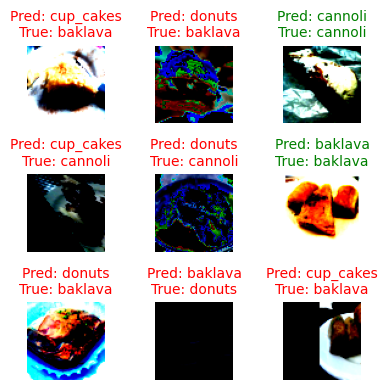

In [34]:
show_random_predictions(model_0, test_data, class_names)

In [35]:
online_image_path = data_path / "baklava-online.jpg"

In [36]:
online_image_path

PosixPath('data/baklava-online.jpg')

In [37]:
import torchvision

In [40]:
single_image = torchvision.io.read_image(str(online_image_path)).type(torch.float32) / 255

Text(0.5, 1.0, 'torch.Size([3, 554, 554])')

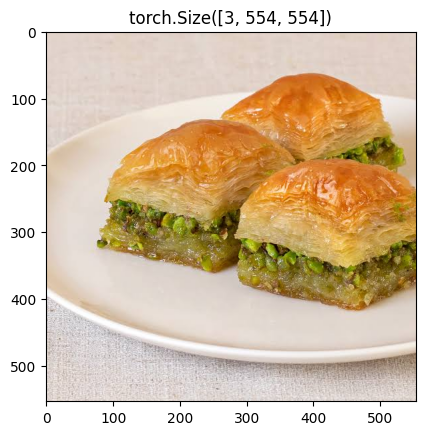

In [41]:
plt.imshow(single_image.permute(1,2,0))
plt.title(single_image.shape)

In [42]:
single_image_transform = transforms.Compose([
    transforms.Resize(size=(64,64))
])

single_image = single_image_transform(single_image)

In [43]:
single_image.shape

torch.Size([3, 64, 64])

In [44]:
single_image = single_image.unsqueeze(dim = 0)

In [45]:
model_0.eval()
with torch.inference_mode():
    y_pred = torch.argmax(model_0(single_image)).item()
print("Predicted Class is : ", class_names[y_pred])

Predicted Class is :  cannoli
